In [4]:
import torch as tc
import matplotlib.pyplot as plt

tc.set_default_dtype(tc.float64)
tc.manual_seed(42)


In [5]:
def func(x):
    """Two-dimensional Rastrigin function (global minimum at [0, 0])."""
    return 20 + tc.sum(x**2 - 10 * tc.cos(2 * tc.pi * x), dim=-1)

lower_bound = -5.12
upper_bound = 5.12

grid = tc.linspace(lower_bound, upper_bound, 200)
x1_grid, x2_grid = tc.meshgrid(grid, grid, indexing="ij")
points = tc.stack((x1_grid, x2_grid), dim=-1)
z_grid = func(points)


Melhor x: [9.574739183126112e-10, 5.175833292123744e-09]
Melhor f(x): 7.105427357601002e-15


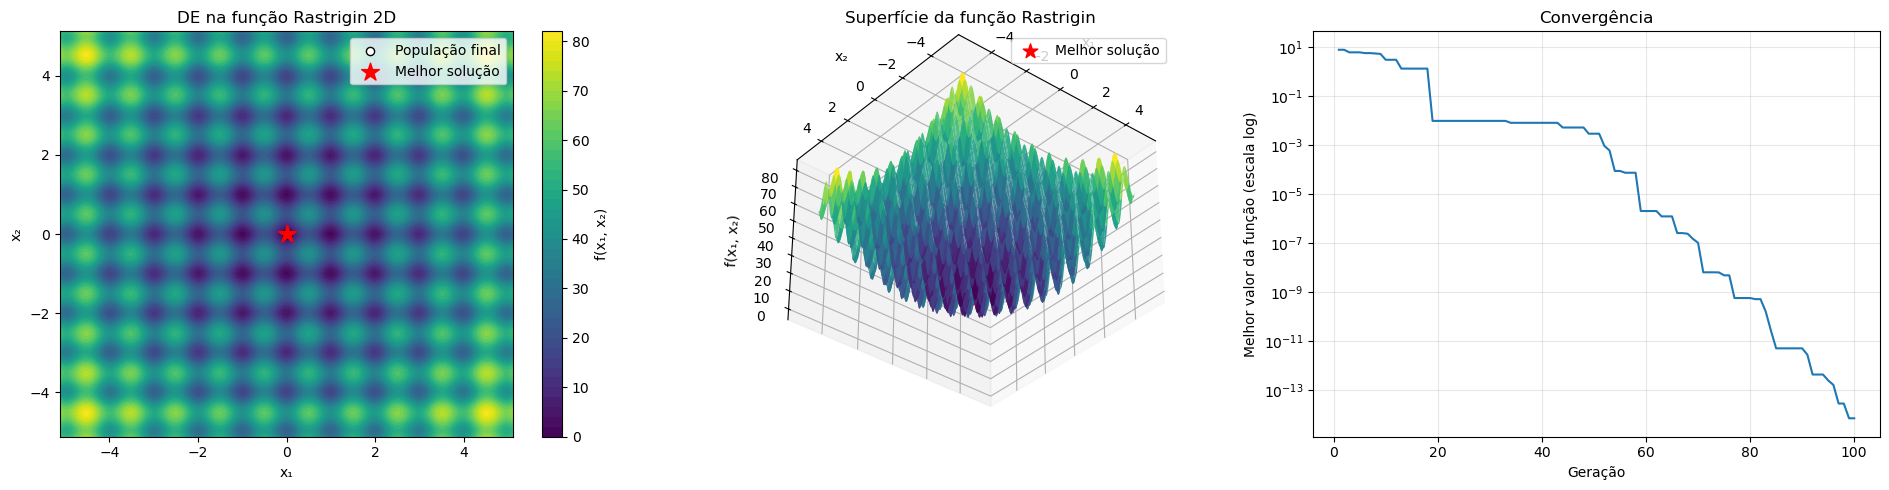

In [8]:
NP = 30
D = 2
F = 0.5
CR = 0.9

max_it = 100

# população inicial
current_pop = (
    lower_bound
    + (upper_bound - lower_bound) * tc.rand(NP, D)
)

new_pop = tc.zeros_like(current_pop)
best_history = []


for _ in range(max_it):

    # para cada indivíduo da população
    for i in range(NP):

        # --------------------------------
        # 1. Escolher r1, r2, r3
        # --------------------------------

        # índices diferentes de i
        available = tc.arange(NP)
        available = available[available != i]

        indices = available[tc.randperm(NP - 1)[:3]]

        i1, i2, i3 = indices

        r1 = current_pop[i1]
        r2 = current_pop[i2]
        r3 = current_pop[i3]

        # --------------------------------
        # 2. Mutação DE/rand/1
        # --------------------------------

        mutant = r1 + F * (r2 - r3)

        # manter dentro dos limites
        mutant = tc.clamp(
            mutant,
            lower_bound,
            upper_bound
        )

        # --------------------------------
        # 3. Cruzamento binomial
        # --------------------------------

        crossover_mask = tc.rand(D) < CR
        crossover_mask[tc.randint(D, (1,))] = True
        trial = tc.where(crossover_mask, mutant, current_pop[i])

        # --------------------------------
        # 4. Seleção gulosa
        # --------------------------------

        if func(trial) < func(current_pop[i]):
            new_pop[i] = trial
        else:
            new_pop[i] = current_pop[i]

    # --------------------------------
    # 5. Nova geração
    # --------------------------------

    current_pop = new_pop.clone()
    best_history.append(func(current_pop).min().item())


# melhor solução encontrada
fitness = func(current_pop)

best_index = tc.argmin(fitness)

best_x = current_pop[best_index]
best_f = fitness[best_index]

print("Melhor x:", best_x.tolist())
print("Melhor f(x):", best_f.item())

fig = plt.figure(figsize=(19, 5))
ax_contour = fig.add_subplot(1, 3, 1)
ax_surface = fig.add_subplot(1, 3, 2, projection="3d")
ax_convergence = fig.add_subplot(1, 3, 3)

contour = ax_contour.contourf(
    x1_grid, x2_grid, z_grid, levels=40, cmap="viridis"
)
ax_contour.scatter(
    current_pop[:, 0], current_pop[:, 1],
    c="white", edgecolors="black", s=35, label="População final"
)
ax_contour.scatter(
    best_x[0], best_x[1],
    c="red", marker="*", s=180, label="Melhor solução"
)
ax_contour.set(
    title="DE na função Rastrigin 2D", xlabel="x₁", ylabel="x₂"
)
ax_contour.legend()
fig.colorbar(contour, ax=ax_contour, label="f(x₁, x₂)")

surface = ax_surface.plot_surface(
    x1_grid, x2_grid, z_grid, cmap="viridis",
    linewidth=0, antialiased=True, alpha=0.9
)
ax_surface.scatter(
    best_x[0], best_x[1], best_f,
    c="red", marker="*", s=120, label="Melhor solução"
)
ax_surface.set(
    title="Superfície da função Rastrigin",
    xlabel="x₁", ylabel="x₂", zlabel="f(x₁, x₂)"
)
ax_surface.view_init(elev=35, azim=-130)
ax_surface.legend()

ax_convergence.plot(range(1, max_it + 1), best_history)
ax_convergence.set_yscale("log")
ax_convergence.set(
    title="Convergência", xlabel="Geração",
    ylabel="Melhor valor da função (escala log)"
)
ax_convergence.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()